In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs 
from cartopy import feature as cfeature
import netCDF4 as nc
from matplotlib.ticker import FuncFormatter
from scipy.spatial import cKDTree
import geopandas as gpd
from cartopy.feature import ShapelyFeature 
print('done')

done


In [2]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

In [ ]:
df = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv', skiprows=1)
lat_all = df['Latitude'].values
lon_all = df['Longitude'].values + 360
lon_all_wrapped = ((lon_all + 180) % 360) - 180

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.1_BB/atm/hist/MUSICA_production3.1_BB.cam.h4.2017-12.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-01.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-02.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-03.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-04.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-05.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-06.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-07.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-08.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-09.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-10.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-11.nc",
]
ds_list_BB = [xr.open_dataset(p) for p in file_paths_BB]
ds_all_BB  = xr.concat(ds_list_BB, dim="time") 

print("done")

done


/tmp/ipykernel_1674851/4077096342.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  uk_ie_union = ne_uk_for_mask.unary_union


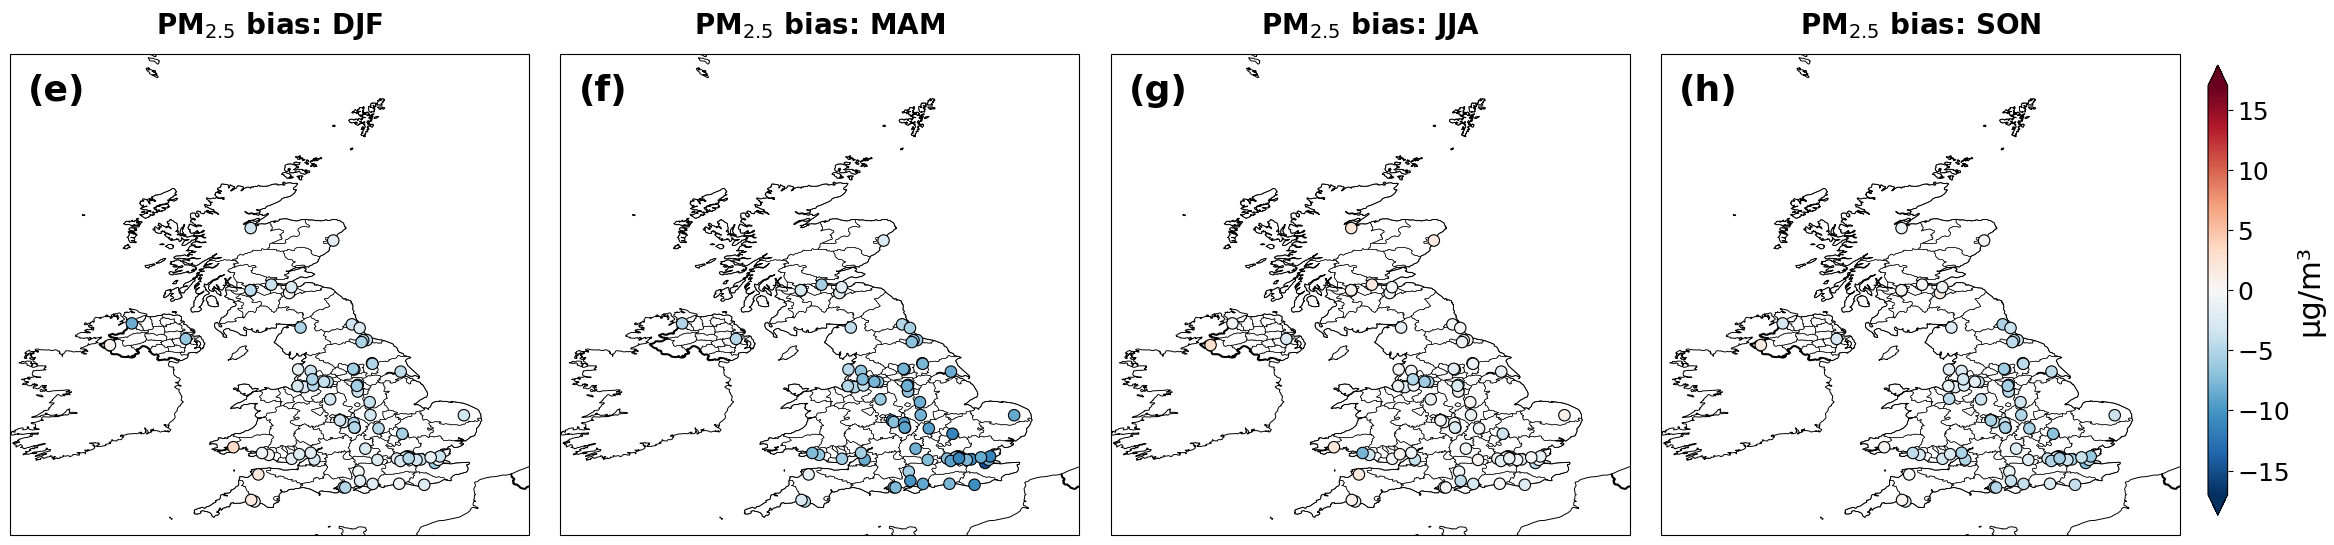

In [ ]:

season_months = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}
season_model = {}
for s, months in season_months.items():
    sel = ds_all_BB.sel(time=ds_all_BB['time'].dt.month.isin(months))
    season_model[s] = (sel['PM25'].mean(dim='time').isel(lev=-1) * 1e9).values

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]
lon_scrip_wrapped = ((lon_scrip + 180) % 360) - 180
tree = cKDTree(np.column_stack([lon_scrip_wrapped, lat_scrip]))

ne_shp = "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
ne_admin1 = gpd.read_file(ne_shp)
if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

ne_uk_for_mask = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]
uk_ie_union = ne_uk_for_mask.unary_union

points_sites = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lon_all_wrapped, lat_all),
    crs="EPSG:4326"
)
inside_sites = points_sites.geometry.within(uk_ie_union).values

ne_uk_only = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR"])]
uk_admin1_feature = ShapelyFeature(
    ne_uk_only.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='black',  
    linewidth=0.4,
)

seasons = [
    ("DJF", ['2018-12', '2018-01', '2018-02'], 1),
    ("MAM", ['2018-03', '2018-04', '2018-05'], 1),
    ("JJA", ['2018-06', '2018-07', '2018-08'], 1),
    ("SON", ['2018-09', '2018-10', '2018-11'], 1),
]

season_data = []
m = 0.0
for season_name, months, factor in seasons:
    selected_cols = []
    for mth in months:
        selected_cols.extend([col for col in df.columns if str(col).startswith(mth)])
    valobs = df[selected_cols].mean(axis=1).values * factor

    mask_valid = (
        np.isfinite(lon_all_wrapped)
        & np.isfinite(lat_all)
        & np.isfinite(valobs)
        & inside_sites
    )
    lonobs_wrapped = lon_all_wrapped[mask_valid]
    latobs = lat_all[mask_valid]
    valobs_valid = valobs[mask_valid]

    if lonobs_wrapped.size == 0:
        season_data.append({"name": season_name, "lon": np.array([]), "lat": np.array([]), "bias": np.array([])})
        continue

    model_field = season_model[season_name]  
    _, idx_near = tree.query(np.column_stack([lonobs_wrapped, latobs]), k=1)
    model_at_sites = model_field[idx_near]

    bias_sites = model_at_sites - valobs_valid 
    if np.isfinite(bias_sites).any():
        m = max(m, float(np.nanmax(np.abs(bias_sites))))

    season_data.append({
        "name": season_name,
        "lon": lonobs_wrapped,
        "lat": latobs,
        "bias": bias_sites
    })

bias_vmin, bias_vmax = -17, 17

fig, axs = plt.subplots(1, 4, figsize=(28, 9), subplot_kw={'projection': ccrs.PlateCarree()})
letters = ['(e)', '(f)', '(g)', '(h)']
last_sc = None

for i, sd in enumerate(season_data):
    ax = axs[i]
    ax.set_extent([-10.5, 3, 49.5, 62], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=1.5)
    ax.add_feature(uk_admin1_feature)
    cmap_bias = plt.colormaps['RdBu_r']
    norm_bias = plt.Normalize(vmin=bias_vmin, vmax=bias_vmax)

    if sd["lon"].size > 0:
        sc = ax.scatter(sd["lon"], sd["lat"],
                        c=sd["bias"], cmap=cmap_bias, norm=norm_bias,
                        s=68, marker='o',
                        edgecolors='black', linewidths=0.8,
                        transform=ccrs.PlateCarree(), zorder=3)
        last_sc = sc

    ax.set_title(f'PM$_{{2.5}}$ bias: {sd["name"]}', fontsize=20, weight='bold', pad=15)
    ax.text(0.035, 0.96, letters[i], transform=ax.transAxes,
            fontsize=26, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.35', alpha=1))

    def lon_formatter(x, pos=None):
        return "0°" if abs(x) < 1e-9 else (f"{x:.0f}°E" if x > 0 else f"{abs(x):.0f}°W")
    def lat_formatter(y, pos=None):
        return "0°" if abs(y) < 1e-9 else (f"{y:.1f}°N" if y > 0 else f"{abs(y):.1f}°S")
    ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
    ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1)
    ax.tick_params(axis='both', which='minor', labelsize=16, length=4, width=1)

fig.subplots_adjust(wspace=0.06, hspace=0.05)

if last_sc is not None:
    cax = fig.add_axes([0.91, 0.25, 0.007, 0.50])
    cb = fig.colorbar(last_sc, cax=cax, orientation='vertical', extend='both')
    cb.set_label('µg/m³', fontsize=22)
    cb.ax.tick_params(labelsize=18)
